In [14]:
import sys
import json
import pickle
import logging
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, accuracy_score, mean_squared_error, mean_absolute_error, r2_score, log_loss
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from lightgbm import LGBMClassifier, LGBMRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.dummy import DummyClassifier, DummyRegressor
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

# -------------------- Конфигурация --------------------
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "bigdata" / "processed"
ARTIFACTS_DIR = BASE_DIR / "artifacts" / "exp1_baseline_models"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
N_SPLITS = 3
HORIZON = 20
np.random.seed(RANDOM_SEED)

In [15]:
# Загрузка данных
df = pd.read_parquet(PROCESSED_DIR / "combined_features.parquet")
with open(PROCESSED_DIR / "feature_columns.txt") as f:
    feature_cols = [line.strip() for line in f if line.strip()]

feature_cols.append('ticker')

# Подвыборка топ-50 тикеров по объёму (как в exp0)
top_tickers = df.groupby('ticker')['volume'].mean().sort_values(ascending=False).head(50).index.tolist()
df = df[df['ticker'].isin(top_tickers)].copy()
logger.info(f"Данные: {df.shape}, тикеров: {df['ticker'].nunique()}")

# Удаляем строки с NaN в целевой переменной
df = df.dropna(subset=[f'target_binary_{HORIZON}d', f'target_return_{HORIZON}d'])

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)
ohe.fit(df[['ticker']].astype(str))

2026-05-22 20:57:45,227 [INFO] Данные: (154766, 124), тикеров: 50


,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'int'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [16]:
# -------------------- Временной сплит (TimeSeriesSplit) --------------------
# Поскольку данные идут блоками по датам, мы используем уникальные даты для разбиения
unique_dates = df['date'].unique()
tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=0)   # gap=0 чтобы тест шёл сразу после train

def get_fold_indices(df, train_dates, test_dates):
    """Возвращает индексы строк, попадающих в train и test по календарю."""
    train_idx = df[df['date'].isin(train_dates)].index
    test_idx = df[df['date'].isin(test_dates)].index
    return train_idx, test_idx

# Строим разбиения по датам
folds = []
for train_idx, test_idx in tscv.split(unique_dates):
    train_dates = unique_dates[train_idx]
    test_dates = unique_dates[test_idx]
    folds.append((train_dates, test_dates))

logger.info(f"Создано {len(folds)} временных фолдов")
for i, (train_dates, test_dates) in enumerate(folds):
    logger.info(f"  Fold {i}: train {train_dates[0]} - {train_dates[-1]}, test {test_dates[0]} - {test_dates[-1]}")

2026-05-22 20:57:45,297 [INFO] Создано 3 временных фолдов
2026-05-22 20:57:45,302 [INFO]   Fold 0: train 1999-06-01 00:00:00 - 2005-09-20 00:00:00, test 2005-09-21 00:00:00 - 2012-01-18 00:00:00
2026-05-22 20:57:45,303 [INFO]   Fold 1: train 1999-06-01 00:00:00 - 2012-01-18 00:00:00, test 2012-01-19 00:00:00 - 2018-04-19 00:00:00
2026-05-22 20:57:45,305 [INFO]   Fold 2: train 1999-06-01 00:00:00 - 2018-04-19 00:00:00, test 2018-04-20 00:00:00 - 2024-07-30 00:00:00


In [17]:
# -------------------- Базовые модели --------------------
def get_models(target_type):
    if target_type == 'binary':
        return {
            'catboost': {'class': CatBoostClassifier, 'params': {'cat_features': ['ticker'], 'random_seed': RANDOM_SEED, 'verbose': False, 'allow_writing_files': False}},
            'lightgbm': {'class': LGBMClassifier, 'params': {'random_state': RANDOM_SEED, 'verbose': -1}},
            'xgboost': {'class': XGBClassifier, 'params': {'random_state': RANDOM_SEED, 'verbosity': 0}},
            'random_forest': {'class': RandomForestClassifier, 'params': {'random_state': RANDOM_SEED, 'n_jobs': -1}},
            'logistic': {'class': LogisticRegression, 'params': {'random_state': RANDOM_SEED, 'max_iter': 1000, 'n_jobs': -1}}
        }
    else:  # return
        return {
            'catboost': {'class': CatBoostRegressor, 'params': {'cat_features': ['ticker'], 'random_seed': RANDOM_SEED, 'verbose': False, 'allow_writing_files': False}},
            'lightgbm': {'class': LGBMRegressor, 'params': {'random_state': RANDOM_SEED, 'verbose': -1}},
            'xgboost': {'class': XGBRegressor, 'params': {'random_state': RANDOM_SEED, 'verbosity': 0}},
            'ridge': {'class': Ridge, 'params': {'random_state': RANDOM_SEED}}
        }

def prepare_data(X, model_name):
    if model_name == 'catboost':
        return X
    ticker_encoded = ohe.transform(X[['ticker']].astype(str))
    ticker_columns = ohe.get_feature_names_out(['ticker'])
    ticker_df = pd.DataFrame(ticker_encoded, columns=ticker_columns, index=X.index)
    X = X.drop(columns=['ticker']).join(ticker_df)
    imputer = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    if model_name in ('logistic', 'ridge'):
        scaler = StandardScaler()
        X_scaled = pd.DataFrame(scaler.fit_transform(X_imp), columns=X_imp.columns, index=X_imp.index)
        return X_scaled
    return X_imp

def evaluate(y_true, y_pred, target_type):
    if target_type == 'binary':
        y_pred_class = (y_pred >= 0.5).astype(int)
        return {
            'accuracy': accuracy_score(y_true, y_pred_class),
            'auc': roc_auc_score(y_true, y_pred),
            'logloss': log_loss(y_true, y_pred)
        }
    else:
        return {
            'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
            'mae': mean_absolute_error(y_true, y_pred),
            'r2': r2_score(y_true, y_pred)
        }

In [18]:
def tune_model(model_name, X_train, y_train, X_val, y_val, target_type):
    def objective(trial):
        if model_name == 'catboost':
            params = {
                'depth': trial.suggest_int('depth', 3, 8),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
                'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
                'iterations': trial.suggest_int('iterations', 300, 800)
            }
            model = get_models(target_type)[model_name]['class'](**params, **get_models(target_type)[model_name]['params'])
            cat_features_idx = [list(X_train.columns).index('ticker')] if 'ticker' in X_train.columns else None
            model.fit(
                Pool(X_train, y_train, cat_features=cat_features_idx),
                eval_set=Pool(X_val, y_val, cat_features=cat_features_idx),
                verbose=False, 
                early_stopping_rounds=50
            )
        elif model_name == 'lightgbm':
            params = {
                'num_leaves': trial.suggest_int('num_leaves', 10, 50),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
                'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
                'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 50)
            }
            model = get_models(target_type)[model_name]['class'](**params, **get_models(target_type)[model_name]['params'])
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
        elif model_name == 'xgboost':
            params = {
                'max_depth': trial.suggest_int('max_depth', 3, 8),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
            }
            model = get_models(target_type)[model_name]['class'](**params, **get_models(target_type)[model_name]['params'])
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        else:
            params = {}
            if model_name == 'random_forest':
                params['n_estimators'] = trial.suggest_int('n_estimators', 100, 300)
                params['max_depth'] = trial.suggest_int('max_depth', 5, 15)
            elif model_name == 'logistic':
                params['C'] = trial.suggest_float('C', 0.01, 10.0, log=True)
            elif model_name == 'ridge':
                params['alpha'] = trial.suggest_float('alpha', 0.01, 10.0, log=True)
            model = get_models(target_type)[model_name]['class'](**params, **get_models(target_type)[model_name]['params'])
            model.fit(X_train, y_train)
        
        if target_type == 'binary':
            pred = model.predict_proba(X_val)[:, 1]
            return roc_auc_score(y_val, pred)
        else:
            pred = model.predict(X_val)
            return -np.sqrt(mean_squared_error(y_val, pred))
    
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_SEED), pruner=MedianPruner(n_startup_trials=2))
    study.optimize(objective, n_trials=5, show_progress_bar=False)
    return study.best_params

2026-05-22 20:57:45,379 [INFO] 
Обработка задачи: binary (target: target_binary_20d)
2026-05-22 20:57:45,379 [INFO] 
--- Fold 1/3 ---


2026-05-22 20:57:45,541 [INFO]     Модель: catboost
[I 2026-05-22 20:57:45,556] A new study created in memory with name: no-name-9c479794-e274-4dde-8e80-11533040ae0a
[I 2026-05-22 20:57:47,009] Trial 0 finished with value: 0.5484638127415283 and parameters: {'depth': 5, 'learning_rate': 0.08927180304353628, 'l2_leaf_reg': 0.8471801418819978, 'iterations': 599}. Best is trial 0 with value: 0.5484638127415283.
[I 2026-05-22 20:57:48,421] Trial 1 finished with value: 0.464324340584139 and parameters: {'depth': 3, 'learning_rate': 0.01432169828911152, 'l2_leaf_reg': 0.0017073967431528124, 'iterations': 733}. Best is trial 0 with value: 0.5484638127415283.
[I 2026-05-22 20:57:50,704] Trial 2 finished with value: 0.5312727171629746 and parameters: {'depth': 6, 'learning_rate': 0.051059032093947576, 'l2_leaf_reg': 0.0012087541473056963, 'iterations': 785}. Best is trial 0 with value: 0.5484638127415283.
[I 2026-05-22 20:57:53,427] Trial 3 finished with value: 0.524862802578368 and parameters:

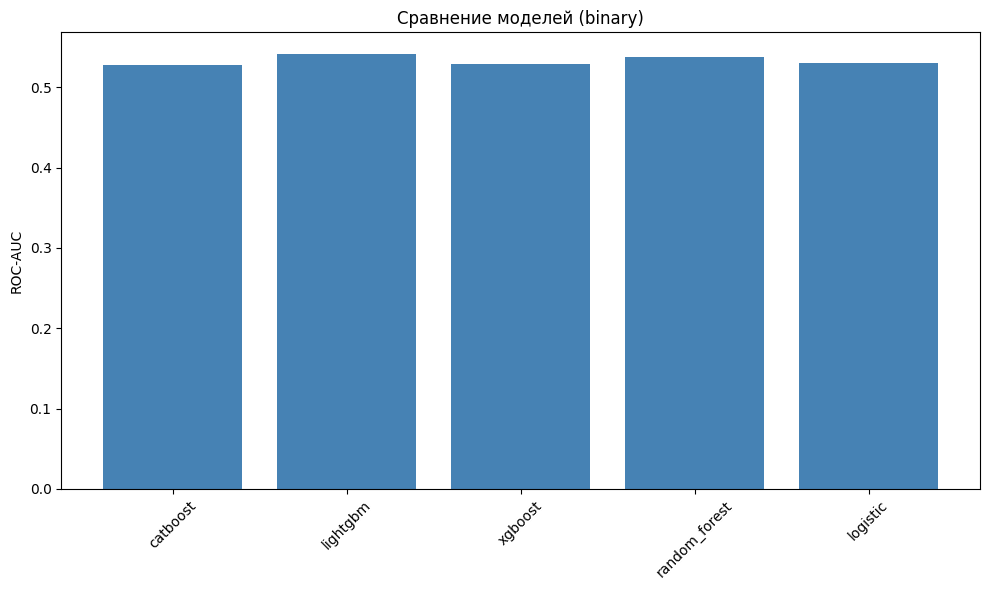

2026-05-22 21:01:39,275 [INFO] 
Обработка задачи: return (target: target_return_20d)
2026-05-22 21:01:39,275 [INFO] 
--- Fold 1/3 ---
2026-05-22 21:01:39,444 [INFO]     Модель: catboost
[I 2026-05-22 21:01:39,451] A new study created in memory with name: no-name-44b6a2ec-fd23-4b07-82e8-3d139cdbcba7
[I 2026-05-22 21:01:40,493] Trial 0 finished with value: -0.09931947062000332 and parameters: {'depth': 5, 'learning_rate': 0.08927180304353628, 'l2_leaf_reg': 0.8471801418819978, 'iterations': 599}. Best is trial 0 with value: -0.09931947062000332.
[I 2026-05-22 21:01:41,109] Trial 1 finished with value: -0.09882278826227985 and parameters: {'depth': 3, 'learning_rate': 0.01432169828911152, 'l2_leaf_reg': 0.0017073967431528124, 'iterations': 733}. Best is trial 1 with value: -0.09882278826227985.
[I 2026-05-22 21:01:42,390] Trial 2 finished with value: -0.09926921269391072 and parameters: {'depth': 6, 'learning_rate': 0.051059032093947576, 'l2_leaf_reg': 0.0012087541473056963, 'iterations':

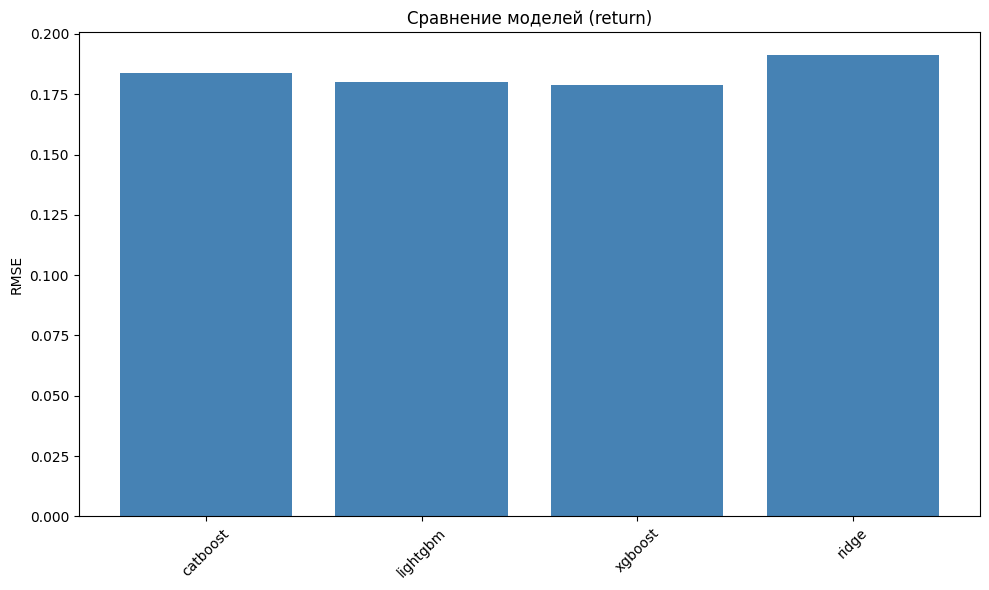

2026-05-22 21:03:23,330 [INFO] 
Эксперимент 1 завершён. Результаты сохранены в artifacts/exp1_baseline_models



Итоговые метрики:

BINARY:
  catboost: {'accuracy': np.float64(0.5272065333047898), 'accuracy_std': np.float64(0.018796178659801894), 'auc': np.float64(0.5281818813401468), 'auc_std': np.float64(0.03986648193087456), 'logloss': np.float64(0.8903371273151982), 'logloss_std': np.float64(0.222311010373067)}
  lightgbm: {'accuracy': np.float64(0.5317500999904617), 'accuracy_std': np.float64(0.019943812933361903), 'auc': np.float64(0.5415737337233546), 'auc_std': np.float64(0.022742073630457806), 'logloss': np.float64(0.7106598148284711), 'logloss_std': np.float64(0.018683530927469074)}
  xgboost: {'accuracy': np.float64(0.5246366598993735), 'accuracy_std': np.float64(0.008880725566541993), 'auc': np.float64(0.529137360111577), 'auc_std': np.float64(0.01970186305372147), 'logloss': np.float64(0.7438946290193443), 'logloss_std': np.float64(0.06034290781013422)}
  random_forest: {'accuracy': np.float64(0.5298952026465167), 'accuracy_std': np.float64(0.005572286862356528), 'auc': np.float64(0

In [19]:
# -------------------- Кросс-валидация --------------------
all_results = {}

for target_type, target_col in [('binary', f'target_binary_{HORIZON}d'), ('return', f'target_return_{HORIZON}d')]:
    logger.info(f"\n{'='*60}\nОбработка задачи: {target_type} (target: {target_col})\n{'='*60}")
    
    models_dict = get_models(target_type)
    cv_results = {model_name: [] for model_name in models_dict}
    
    for fold_idx, (train_dates, test_dates) in enumerate(folds):
        logger.info(f"\n--- Fold {fold_idx+1}/{N_SPLITS} ---")
        train_idx = df[df['date'].isin(train_dates)].index
        test_idx = df[df['date'].isin(test_dates)].index
        
        X_train_raw = df.loc[train_idx, feature_cols]
        y_train = df.loc[train_idx, target_col]
        X_test_raw = df.loc[test_idx, feature_cols]
        y_test = df.loc[test_idx, target_col]
        
        # Внутренний валидационный сплит (последние 20% обучающих дат)
        train_inner_dates = train_dates[:int(0.8*len(train_dates))]
        val_dates = train_dates[int(0.8*len(train_dates)):]
        train_inner_idx = df[df['date'].isin(train_inner_dates)].index
        val_idx = df[df['date'].isin(val_dates)].index
        X_train_inner = df.loc[train_inner_idx, feature_cols]
        y_train_inner = df.loc[train_inner_idx, target_col]
        X_val = df.loc[val_idx, feature_cols]
        y_val = df.loc[val_idx, target_col]
        
        for model_name in models_dict:
            logger.info(f"    Модель: {model_name}")
            try:
                X_train_prep = prepare_data(X_train_inner, model_name)
                X_val_prep = prepare_data(X_val, model_name)
                X_test_prep = prepare_data(X_test_raw, model_name)
                
                best_params = tune_model(model_name, X_train_prep, y_train_inner, X_val_prep, y_val, target_type)
                
                X_train_full = prepare_data(pd.concat([X_train_inner, X_val]), model_name)
                y_train_full = pd.concat([y_train_inner, y_val])
                model = models_dict[model_name]['class'](**best_params, **models_dict[model_name]['params'])
                if model_name == 'catboost':
                    if model_name == 'catboost':
                        cat_features_idx = [list(X_train_full.columns).index('ticker')] if 'ticker' in X_train_full.columns else None
                        model.fit(Pool(X_train_full, y_train_full, cat_features=cat_features_idx), verbose=False)
                else:
                    model.fit(X_train_full, y_train_full)
                
                if target_type == 'binary':
                    pred = model.predict_proba(X_test_prep)[:, 1]
                else:
                    pred = model.predict(X_test_prep)
                
                metrics = evaluate(y_test, pred, target_type)
                cv_results[model_name].append(metrics)
                logger.info(f"        {metrics}")
            except Exception as e:
                logger.error(f"        Ошибка: {e}")
    
    # Агрегация результатов по фолдам
    final_metrics = {}
    for model_name, metrics_list in cv_results.items():
        if not metrics_list:
            continue
        avg_metrics = {}
        for metric in metrics_list[0].keys():
            values = [m[metric] for m in metrics_list]
            avg_metrics[metric] = np.mean(values)
            avg_metrics[f'{metric}_std'] = np.std(values)
        final_metrics[model_name] = avg_metrics
    
    all_results[target_type] = final_metrics
    
    # Сохраняем результаты
    with open(ARTIFACTS_DIR / f'results_{target_type}.json', 'w') as f:
        json.dump(final_metrics, f, indent=2, default=str)
    
    # График сравнения для данного типа
    plt.figure(figsize=(10,6))
    models = list(final_metrics.keys())
    if target_type == 'binary':
        scores = [final_metrics[m]['auc'] for m in models]
        ylabel = 'ROC-AUC'
    else:
        scores = [final_metrics[m]['rmse'] for m in models]
        ylabel = 'RMSE'
    plt.bar(models, scores, color='steelblue')
    plt.ylabel(ylabel)
    plt.title(f'Сравнение моделей ({target_type})')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / f'model_comparison_{target_type}.png', dpi=150)
    plt.show()

logger.info("\nЭксперимент 1 завершён. Результаты сохранены в artifacts/exp1_baseline_models")
print("\nИтоговые метрики:")
for target_type, metrics_dict in all_results.items():
    print(f"\n{target_type.upper()}:")
    for model, met in metrics_dict.items():
        print(f"  {model}: {met}")